In [1]:
%pip install scikit-learn

import cv2
import os
import numpy as np
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report
import random

Note: you may need to restart the kernel to use updated packages.


In [2]:
def im2double(img):   
    return img.astype(np.float64) / 255.0

In [3]:
def load_images_folder(directory):
    bins = 128 
    data = []
    labels = []
    row = 128
    column = 128
    # Loading of all sub-folders in the directory
    for subdir in os.listdir(directory):
        subdir_path = os.path.join(directory, subdir)
        
    # Getting path of image files one-by-one from a sub-folder 'subdir_path'   
        if os.path.isdir(subdir_path):  
            for filename in os.listdir(subdir_path):
                filepath = os.path.join(subdir_path, filename)
                
                #Checking whether obtained path is a filepath
                if os.path.isfile(filepath):
                    
                    # Load and preprocess image (resize to uniform size)
                    image = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)  # Convert to grayscale using argument as cv2.IMREAD_GRAYSCALE
                    
                    # image = cv2.resize(image, (row, column),interpolation=cv2.INTER_CUBIC)  # Resize to 64x64 pixels
                    image = cv2.resize(image, (row, column), interpolation=cv2.INTER_LINEAR)

                    #image = cv2.normalize(image.astype('float'), None, 0.0, 1.0, cv2.NORM_MINMAX)
                    '''blue, green, red = cv2.split(image)
                    arr1 = np.histogram(blue.flatten(),30)
                    arr2 = np.histogram(green.flatten(),30)
                    arr3 = np.histogram(red.flatten(), 30)
                    x= np.concatenate([arr1[0], arr2[0], arr3[0]])
                    data.append(x)'''


                    '''
                    arr = image.flatten() #flattening the image of size 64x64 to make one-dimentional array
                    arr1 = np.histogram(arr,bins) #Computation of histogram of the array with 256 bins                    
                    arr1 = [x/tp for x in arr1]
                    data.append(arr1[0])'''

                    # Compute histogram
                    hist = cv2.calcHist([image], [0], None, [bins], [0, 256])
                    hist_normalized = hist / hist.sum()
                    data.append(hist_normalized[:,0])
                    
                    
                    #arr1 = [np.average(arr), np.max(arr), np.median(arr), np.var(arr)]  #Other features
                    #data.append(arr1)
                    
                    #data.append(image.flatten())  # Flatten the image

                    #Assigning suitable lables to different classes
                   
                    if subdir == 'dogs':
                        labels.append(0)  # May use the folder name as the label
                    elif subdir == 'cats':
                        labels.append(1)
                    else:
                        labels.append(2)

    return np.array(data), np.array(labels)  #Convering results to Numpy arrays

In [4]:
# Path to the dataset
dataset_directory1 = r"C:\D folder\Programming\programs\my codes\ML codes\knn classifier\Dog-Cat Dataset\train" 
dataset_directory2 = r"C:\D folder\Programming\programs\my codes\ML codes\knn classifier\Dog-Cat Dataset\test"

# Load images and labels
features_train, labels_train = load_images_folder(dataset_directory1)
features_test, labels_test = load_images_folder(dataset_directory2)

In [5]:
#features_train = features_train.astype(np.float64)
#features_test = features_test.astype(np.float64)



In [6]:
#Standardization
sc = StandardScaler()
X_train_scaled = sc.fit_transform(features_train)
X_test_scaled = sc.transform(features_test)

In [7]:
X_train_scaled_meaned = X_train_scaled - np.mean(X_train_scaled, axis=0)
covariance_matrix = np.cov(X_train_scaled_meaned, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)
# Step 4: Sort Eigenvectors by Descending Eigenvalues

sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]
# Step 5: Select Top k Components
eigenvectors_reduced = eigenvectors[:, :1]

# Step 6: Project Data to Lower Dimensions
X_train_pca = np.dot(X_train_scaled_meaned, eigenvectors_reduced)

X_test_scaled_meaned = X_test_scaled - np.mean(X_train_scaled, axis=0)
X_test_pca = np.dot(X_test_scaled_meaned, eigenvectors_reduced)

In [8]:
pca = PCA(n_components=1)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
#X_train_pca = X_train_scaled
#X_test_pca = X_test_scaled

In [9]:
import random
start = 0
end = len(labels_test)
n = len(labels_test)  # Number of random integers
r = random.sample(range(start, end), n)

In [ ]:
from sklearn.multiclass import OneVsRestClassifier
svm_model = SVC(kernel='rbf', C=0.1, gamma=2)  # Equivalent to MATLAB 'KernelScale', 2 and 'BoxConstraint', 0.1
svm_ovr = OneVsRestClassifier(svm_model)  # Equivalent to MATLAB's fitcecoc (One-vs-Rest multi-class SVM)

svm_ovr.fit(X_train_pca, labels_train)  # Train the SVM model
y_pred = svm_ovr.predict(X_test_pca[r[:100], :])  # Predict first 100 test samples

accuracy = 100 * accuracy_score(labels_test[r[:100]], y_pred)
ac = [accuracy]

In [11]:
PC_opt = np.argmax(ac) + 1  # MATLAB indices start from 1, so add 1
X_train_pca_opt = (X_train_scaled - np.mean(X_train_scaled, axis=0)) @ eigenvectors[:, :PC_opt]
X_test_pca_opt = (X_test_scaled - np.mean(X_train_scaled, axis=0)) @ eigenvectors[:, :PC_opt]

In [12]:
svm_ovr_opt = OneVsRestClassifier(SVC(kernel='rbf', C=0.1, gamma=2))
svm_ovr_opt.fit(X_train_pca_opt, labels_train)  # Train again with optimal PCA components

y_pred_final = svm_ovr_opt.predict(X_test_pca_opt[r[101:], :])  # Final test set predictions
accuracy_final = 100 * accuracy_score(labels_test[r[101:]], y_pred_final)

print(f"Final Accuracy: {accuracy_final:.2f}%")

Final Accuracy: 37.21%


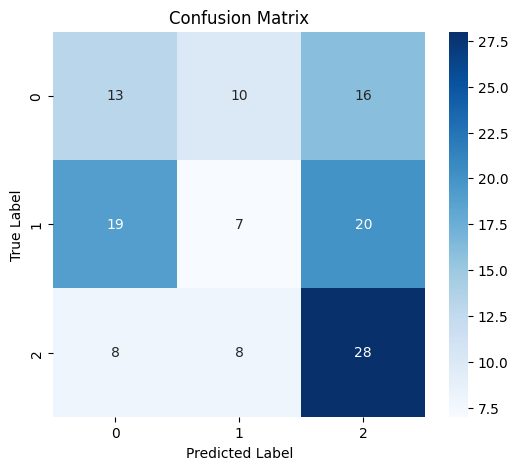

In [ ]:
# conf_matrix = confusion_matrix(labels_test[r[101:]], y_pred_final)

# # Display confusion matrix using seaborn for better visualization
# import seaborn as sns
# import matplotlib.pyplot as plt

# plt.figure(figsize=(6, 5))
# sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
# plt.xlabel("Predicted Label")
# plt.ylabel("True Label")
# plt.title("Confusion Matrix")
# plt.show()

In [17]:

svm_model = SVC(kernel='rbf', C=0.1, gamma='scale')  # 'scale' automatically sets gamma
svm_model.fit(X_train_pca, labels_train)

# Predict on test set
y_pred = svm_model.predict(X_test_pca[r[1:231],:])
accuracy = accuracy_score(labels_test[r[1:231]], y_pred)

print(f"Accuracy: {accuracy * 100:.2f}")

Accuracy: 43.23
